In [18]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
MODEL_NAME = "gemma-4-26b-a4b-it"

In [19]:
from langgraph.graph import StateGraph ,START , END
from typing import TypedDict , Optional
from langgraph.checkpoint.memory import InMemorySaver

In [20]:
class TopicSchema(TypedDict):
    topic: str
    outline: Optional[str]
    section_1: Optional[str]
    section_2: Optional[str]
    section_3: Optional[str]
    finalize_report: Optional[str]

In [21]:
def fetch_topic_outline(state: TopicSchema)-> dict:
    print("Generating outline.....")
    topic = state['topic']
    prompt = f"generates a rough outline for a report on {topic}"
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt
    )
    output = response.text
    print("outline generated successfully.....")
    return {
        "outline":output
    }

In [22]:
# def write_section_1(state: TopicSchema)-> dict:
#     print("Writing section 1.....")
#     prompt = f"write the first section based on outline: {state['outline'] }"
#     response = client.models.generate_content(
#             model=MODEL_NAME,
#             contents=prompt
#         )
#     output = response.text
#     print("section 1 completed.....")
#     return {
#             "section_1":output
#     }

In [36]:
def write_section_2(state: TopicSchema)-> dict:
    print("writing section 2.....")
    prompt = f"write the second section based on outline: {state['outline'] }"
    # intentional_exception = 2/0
    
    print("continuing from where it left off.....")
    response = client.models.generate_content(
            model=MODEL_NAME,
            contents=prompt
        )
    output = response.text
    print("section 2 completed.....")
    return {
            "section_2":output
    }

In [24]:
def write_section_3(state: TopicSchema)-> dict:
    print("writing section 3.....")
    prompt = f"write the third section based on outline: {state['outline'] }"
    response = client.models.generate_content(
            model=MODEL_NAME,
            contents=prompt
        )
    output = response.text
    print("section 3 completed.....")
    return {
            "section_3":output
    }

In [25]:
# def finalize_report(state: TopicSchema)-> dict:
#     complete_report = f"""topic : {state['topic']} \n 
#     outline :\n {state['outline']} \n
#     section 1 :\n {state['section_1']} \n 
#     section 2 :\n {state['section_2']} \n
#     section 3 :\n {state['section_3']}
# """
#     return {
#         "finalize_report" : complete_report
#     }

In [37]:
graph = StateGraph(TopicSchema)
graph.add_node("fetch_topic_outline",fetch_topic_outline)
# graph.add_node("write_section_1",write_section_1)
graph.add_node("write_section_2",write_section_2)
graph.add_node("write_section_3",write_section_3)
# graph.add_node("finalize_report",finalize_report)

In [38]:
graph.add_edge(START,'fetch_topic_outline')
graph.add_edge('fetch_topic_outline','write_section_2')
# graph.add_edge('write_section_1','write_section_2')
graph.add_edge('write_section_2','write_section_3')
# graph.add_edge('write_section_3','finalize_report')
graph.add_edge('write_section_3',END)

In [28]:
checkpointer = InMemorySaver()

In [39]:

app = graph.compile(checkpointer=checkpointer)

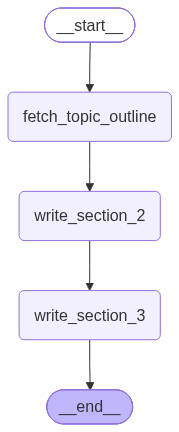

In [40]:
app

In [31]:
config = {"configurable": {"thread_id": "1"}}

In [32]:
try:
    app.invoke({'topic':"Independence Day"},config=config)
except Exception as e:
    print("Simulated crash:", e)
    print("remove the 2/0 from section 2 now and call another invoke in below cell")


Generating outline.....
outline generated successfully.....
writing section 2.....
Simulated crash: division by zero
remove the 2/0 from section 2 now and call another invoke in below cell


In [33]:
app.get_state(config)

StateSnapshot(values={'topic': 'Independence Day', 'outline': 'Since "Independence Day" can refer to many different countries, I have provided two types of outlines: **Option 1** is a general template you can use for *any* country, and **Option 2** is a specific outline for the **United States Independence Day**.\n\n---\n\n### Option 1: The Universal Outline\n*Use this if you are writing about the independence of a specific country (e.g., India, Philippines, Mexico, etc.).*\n\n**I. Introduction**\n* **A. Definition:** Define what Independence Day means for this specific nation.\n* **B. Date and Significance:** State the date and why it is the most important day in the country\'s calendar.\n* **C. Thesis Statement:** A brief overview of how the struggle for independence shaped the nation’s identity.\n\n**II. Historical Background**\n* **A. Pre-Independence Era:** Describe the political/colonial state of the country before independence.\n* **B. Causes of the Movement:** Economic, social,

In [41]:
app.invoke(None, config=config)

writing section 2.....
continuing from where it left off.....
section 2 completed.....
writing section 3.....
section 3 completed.....


{'topic': 'Independence Day',
 'outline': 'Since "Independence Day" can refer to many different countries, I have provided two types of outlines: **Option 1** is a general template you can use for *any* country, and **Option 2** is a specific outline for the **United States Independence Day**.\n\n---\n\n### Option 1: The Universal Outline\n*Use this if you are writing about the independence of a specific country (e.g., India, Philippines, Mexico, etc.).*\n\n**I. Introduction**\n* **A. Definition:** Define what Independence Day means for this specific nation.\n* **B. Date and Significance:** State the date and why it is the most important day in the country\'s calendar.\n* **C. Thesis Statement:** A brief overview of how the struggle for independence shaped the nation’s identity.\n\n**II. Historical Background**\n* **A. Pre-Independence Era:** Describe the political/colonial state of the country before independence.\n* **B. Causes of the Movement:** Economic, social, or political reason

In [42]:
app.get_state(config)

StateSnapshot(values={'topic': 'Independence Day', 'outline': 'Since "Independence Day" can refer to many different countries, I have provided two types of outlines: **Option 1** is a general template you can use for *any* country, and **Option 2** is a specific outline for the **United States Independence Day**.\n\n---\n\n### Option 1: The Universal Outline\n*Use this if you are writing about the independence of a specific country (e.g., India, Philippines, Mexico, etc.).*\n\n**I. Introduction**\n* **A. Definition:** Define what Independence Day means for this specific nation.\n* **B. Date and Significance:** State the date and why it is the most important day in the country\'s calendar.\n* **C. Thesis Statement:** A brief overview of how the struggle for independence shaped the nation’s identity.\n\n**II. Historical Background**\n* **A. Pre-Independence Era:** Describe the political/colonial state of the country before independence.\n* **B. Causes of the Movement:** Economic, social,